# Swiss-roll demonstration

This notebook runs all eight reverse-OU methods with identical inputs on a noisy two-coordinate Swiss-roll projection scaled by 1/5. The default execution uses 300 training samples, 10,000 reference samples, 2,000 generated particles, and 300 reverse steps. Results are qualitative and are not a superiority claim.

## Methods

The columns show plain score matching, Stein-informed score matching, scalar Stein transport, and vectorized Stein transport. The rows distinguish deterministic probability-flow and stochastic reverse-SDE sampling.

In [1]:
import json
import os

import torch
from IPython.display import Image, Markdown, display

from stein_generative_modeling.swiss_roll import (
    SwissRollConfig,
    run_experiment,
    smoke_config,
)

In [2]:
mode = os.environ.get("STEIN_NOTEBOOK_MODE", "full").lower()
if mode not in {"full", "smoke"}:
    raise ValueError("STEIN_NOTEBOOK_MODE must be 'full' or 'smoke'")
config = smoke_config() if mode == "smoke" else SwissRollConfig()
display(Markdown(f"**Execution mode:** `{mode}`"))
config

**Execution mode:** `full`

SwissRollConfig(dimension=2, parameter_lower=4.71238898038469, parameter_upper=14.137166941154069, pre_scale_noise_std=1.0, coordinate_scale=5.0, training_size=300, reference_size=10000, generated_size=2000, horizon=3.0, reverse_steps=300, regularization=0.001, scaling_factor=1.0, device='cpu', dtype='float64', seeds={'training': 5025, 'reference': 5026, 'initial_particles': 5027, 'forward_noise': 5028, 'reverse_brownian': 5029})

In [3]:
run_dir = run_experiment(config, progress=False)
print(f"Completed run: {run_dir.name}")

Completed run: seed5025_20260923T210507.272043Z


In [4]:
resolved = json.loads((run_dir / "config.json").read_text())
metadata = json.loads((run_dir / "run_metadata.json").read_text())
outputs = torch.load(run_dir / "samples.pt", map_location="cpu", weights_only=False)
status = {name: item["status"] for name, item in outputs.items()}
display(
    {
        "configuration": resolved,
        "method_status": status,
        "failures": metadata["failures"],
    }
)

{'configuration': {'coordinate_scale': 5.0,
  'device': 'cpu',
  'dimension': 2,
  'dtype': 'float64',
  'effective_noise_std': 0.2,
  'generated_size': 2000,
  'horizon': 3.0,
  'method_labels': {'sm_plain_det': '$\\mathrm{SM}_{\\mathrm{plain}}^{\\mathrm{det}}$',
   'sm_plain_sto': '$\\mathrm{SM}_{\\mathrm{plain}}^{\\mathrm{sto}}$',
   'sm_stein_det': '$\\mathrm{SM}_{\\mathrm{stein}}^{\\mathrm{det}}$',
   'sm_stein_sto': '$\\mathrm{SM}_{\\mathrm{stein}}^{\\mathrm{sto}}$',
   'st_det': '$\\mathrm{ST}^{\\mathrm{det}}$',
   'st_sto': '$\\mathrm{ST}^{\\mathrm{sto}}$',
   'st_vec_det': '$\\mathrm{ST}_{\\mathrm{vec}}^{\\mathrm{det}}$',
   'st_vec_sto': '$\\mathrm{ST}_{\\mathrm{vec}}^{\\mathrm{sto}}$'},
  'methods': ['sm_plain_det',
   'sm_stein_det',
   'st_det',
   'st_vec_det',
   'sm_plain_sto',
   'sm_stein_sto',
   'st_sto',
   'st_vec_sto'],
  'parameter_lower': 4.71238898038469,
  'parameter_upper': 14.137166941154069,
  'plot_limits': {'x1': [-3.5, 3.5], 'x2': [-3.5, 3.5]},
  'pre_s

## Target reference

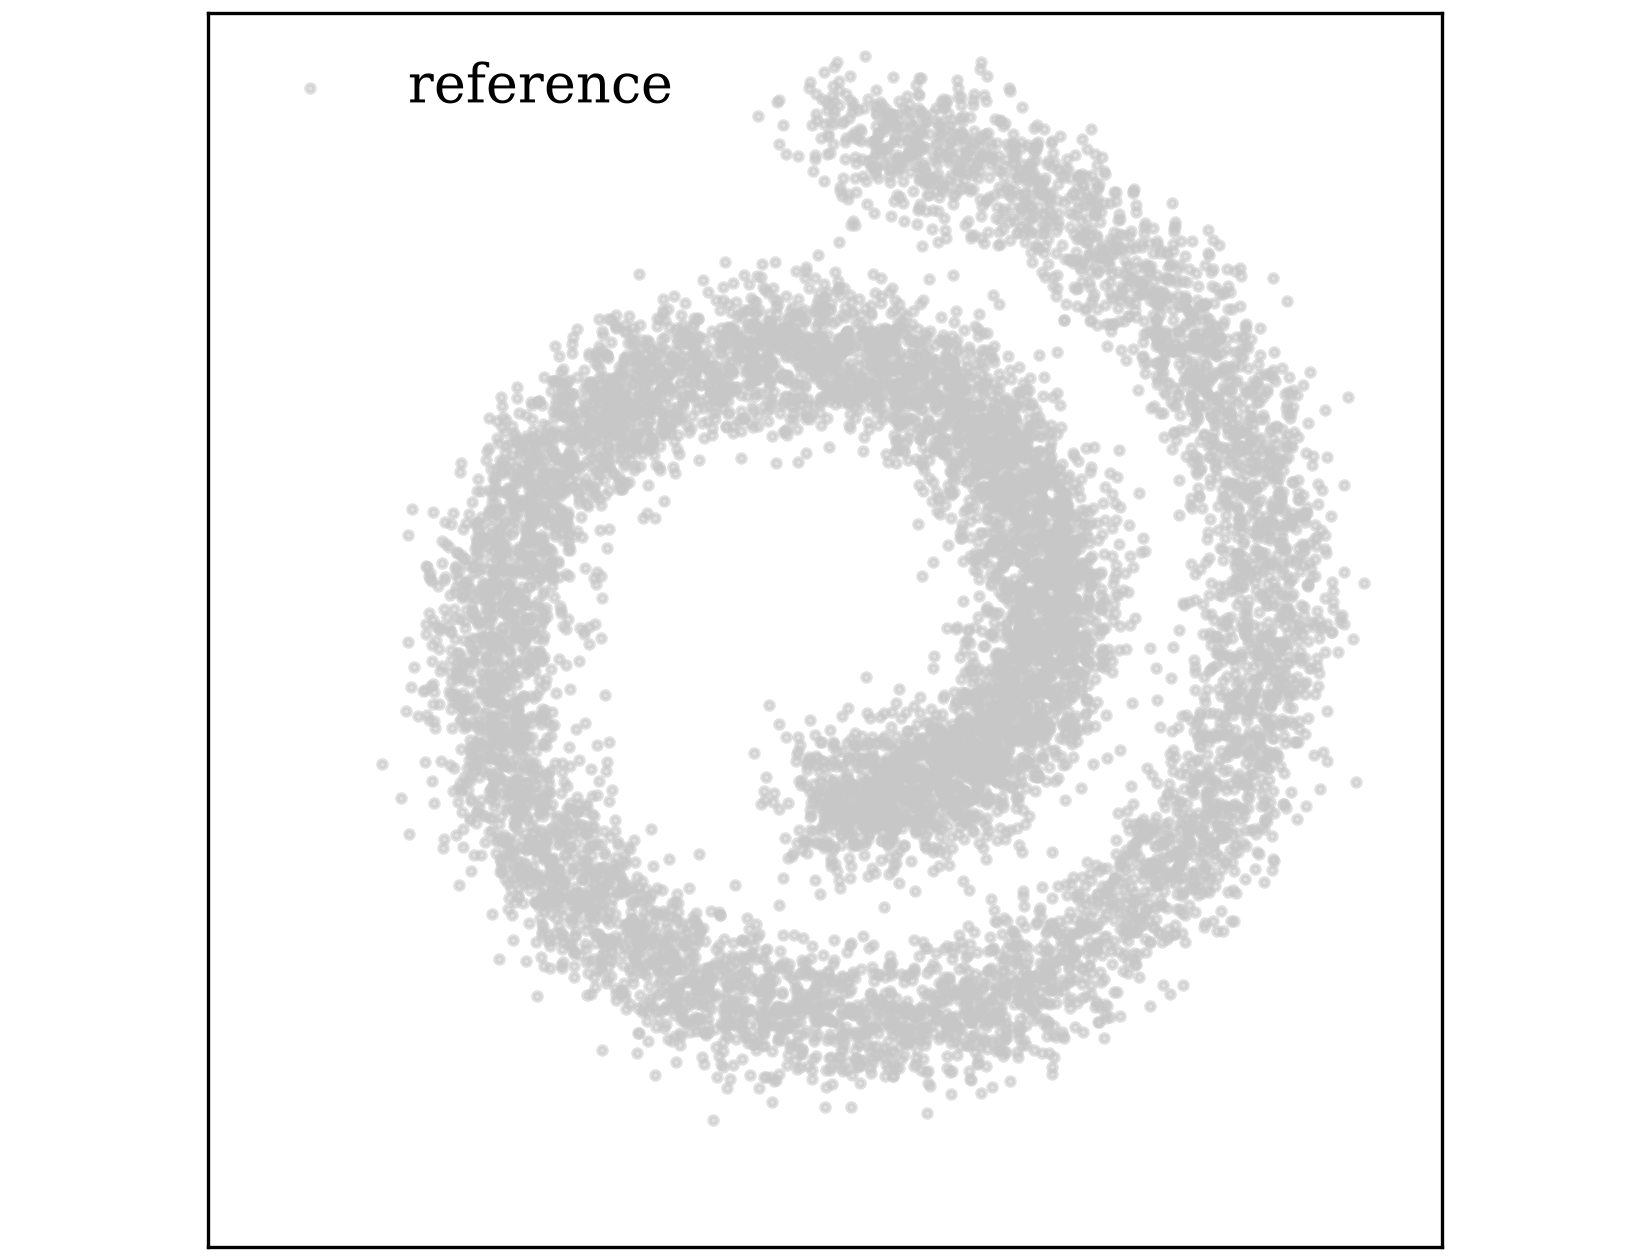

## Eight-method comparison

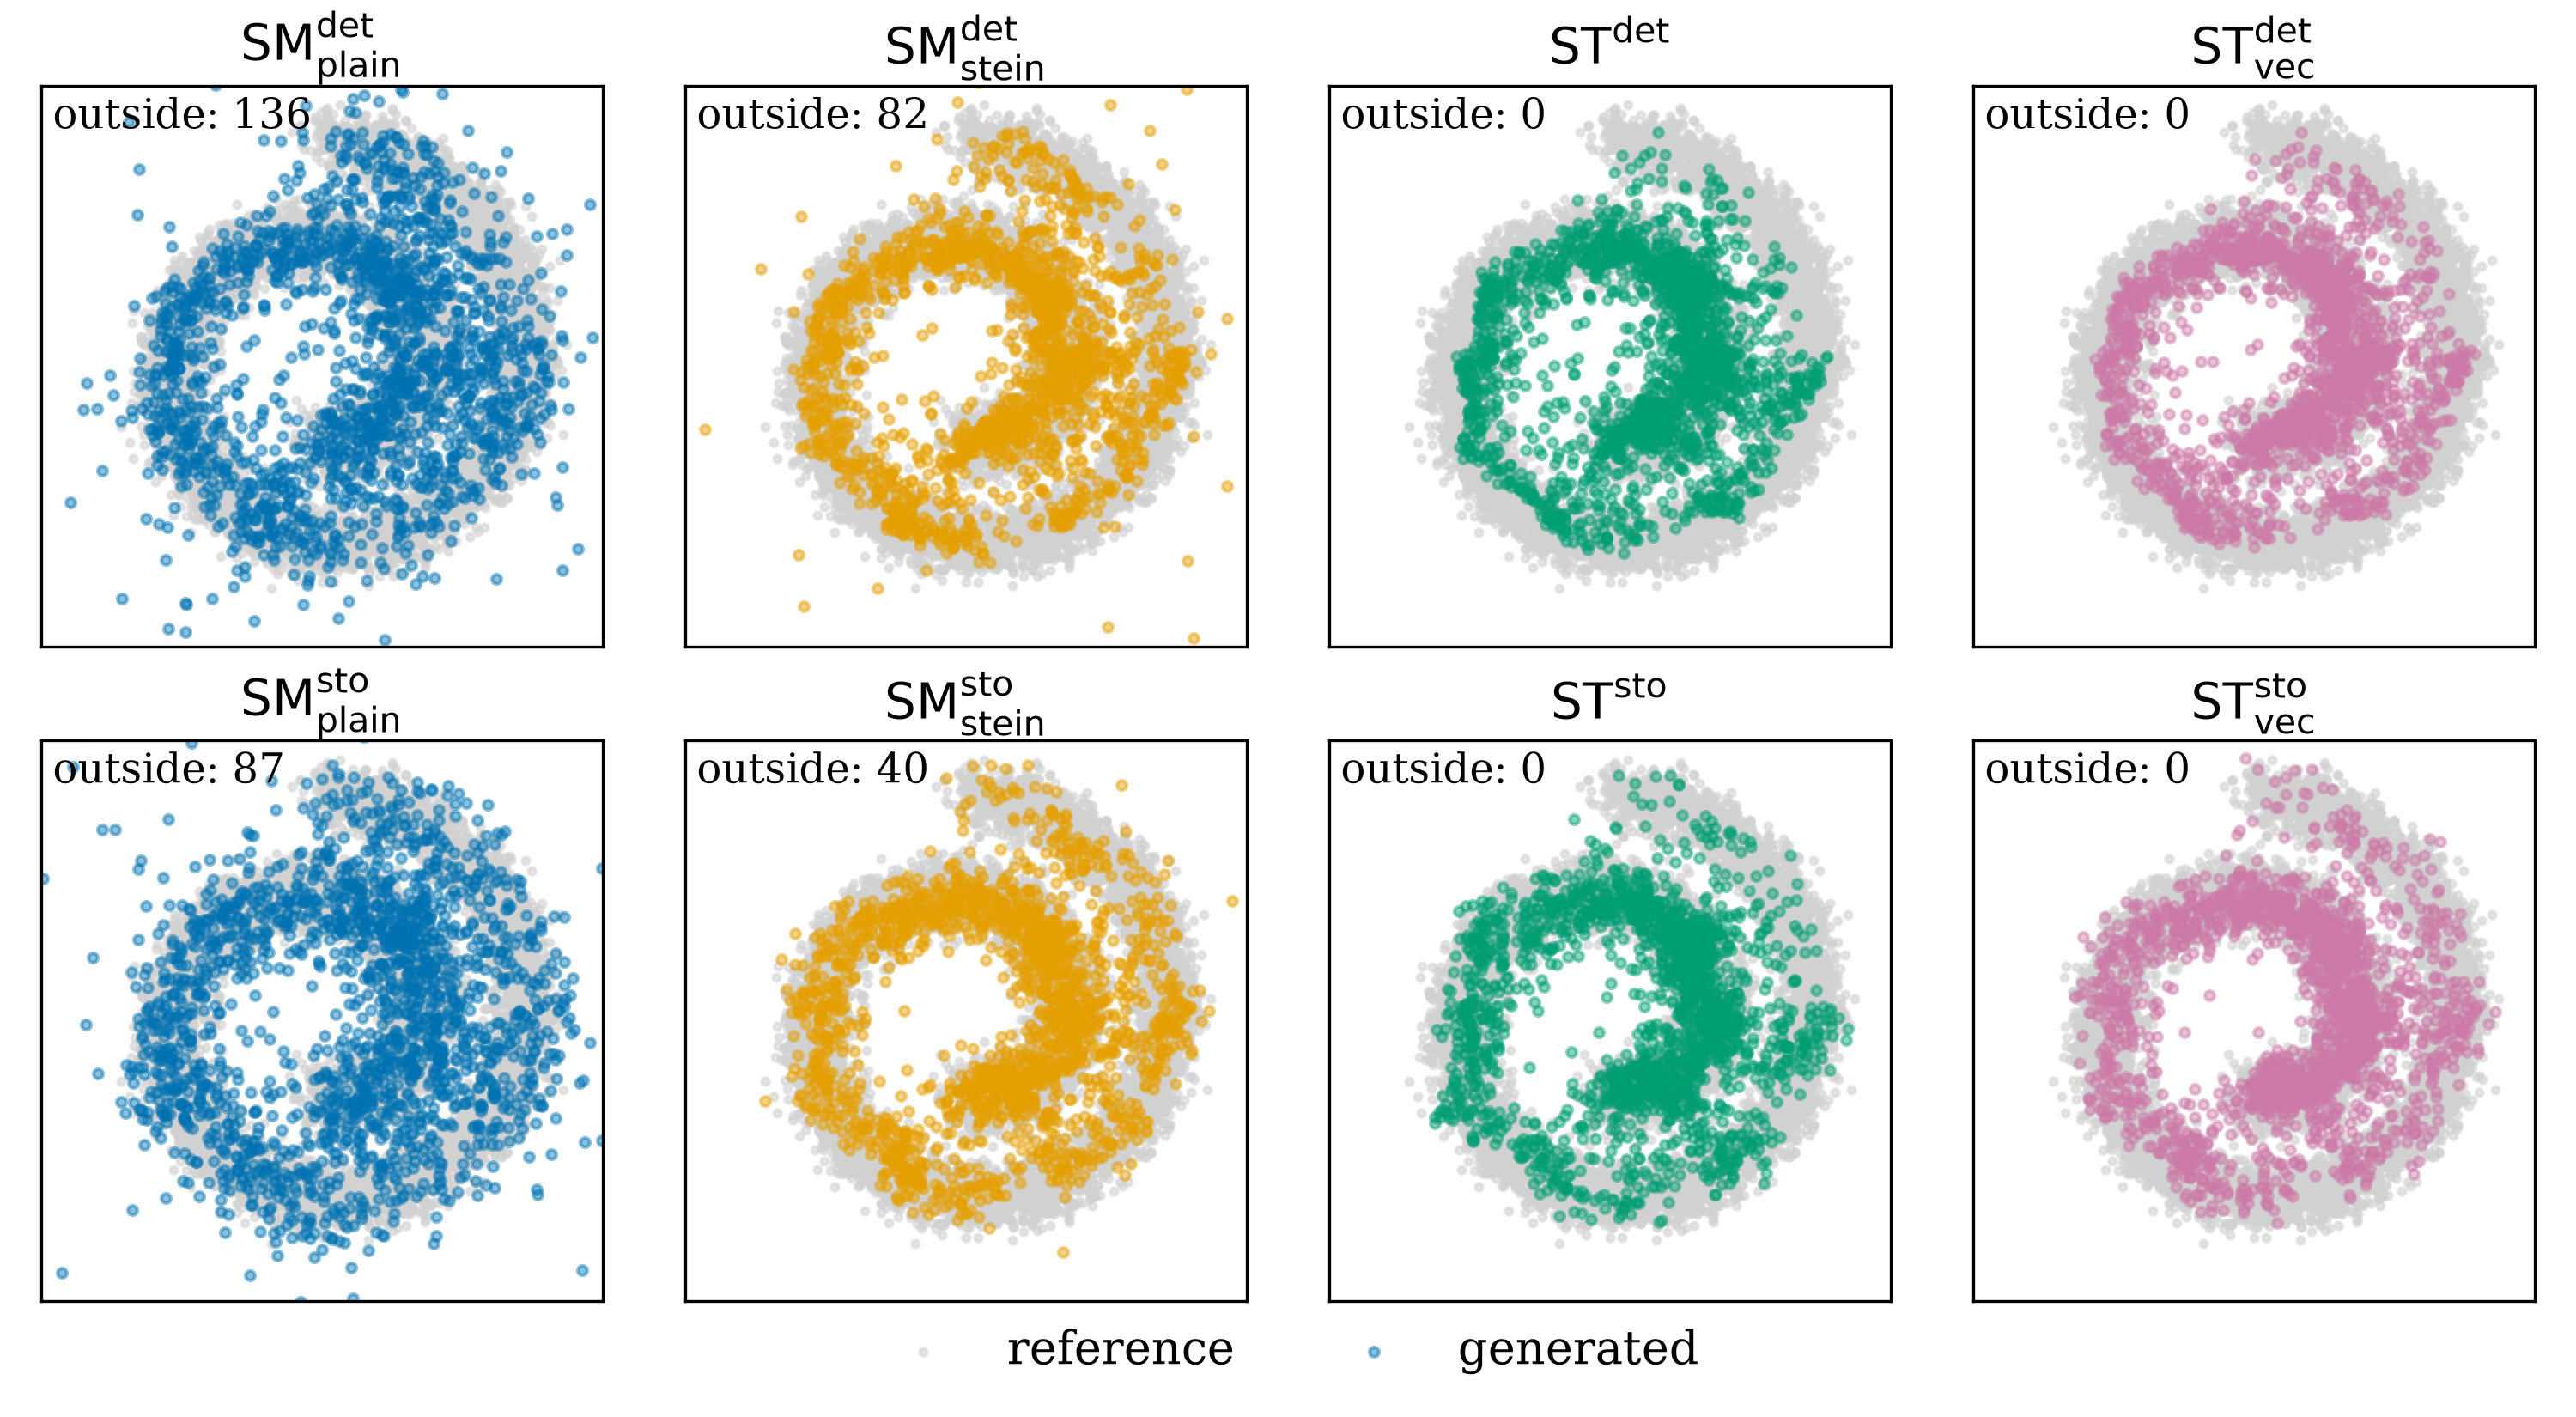

In [5]:
display(Markdown("## Target reference"))
display(Image(filename=str(run_dir / "reference.png")))
display(Markdown("## Eight-method comparison"))
display(Image(filename=str(run_dir / "comparison.png")))